# 02 - Exploratory Data Analysis
Analyzes churn patterns across tenure, contract type, monthly charges, support calls, payment method, and age group. Generates correlation matrix and customer segmentation.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import eda
import os
os.chdir('..')
%matplotlib inline

In [2]:
df = eda.load_clean_data()
df.head()

,CustomerID,Age,Gender,TenureMonths,ContractType,InternetService,PhoneService,StreamingService,MonthlyCharges,TotalCharges,MonthlyUsageGB,SessionsPerMonth,SupportCalls,Complaints,PaymentMethod,PaymentDelayDays,Churn
0,CUST-10000,56,Male,28,Month-to-Month,DSL,Yes,No,21.33,582.37,391.404,25,1,1,Electronic Check,5,No
1,CUST-10001,69,Male,5,One Year,Fiber Optic,Yes,No,66.45,324.76,190.100,54,2,1,Electronic Check,3,Yes
2,CUST-10002,46,Female,21,Month-to-Month,Fiber Optic,Yes,Yes,59.54,1167.50,2.400,48,1,0,Bank Transfer,2,No
3,CUST-10003,32,Female,18,Month-to-Month,Fiber Optic,Yes,Yes,51.23,901.29,204.100,47,0,0,Credit Card,4,Yes
4,CUST-10004,60,Male,47,Two Year,Fiber Optic,Yes,No,47.56,2173.31,91.600,41,1,1,Bank Transfer,3,No


## Churn distribution

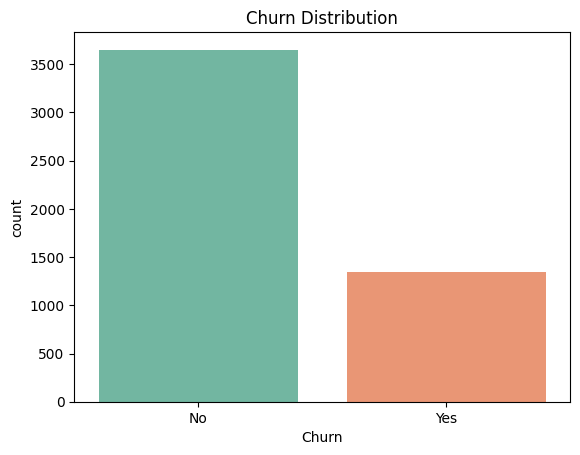

In [3]:
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.show()

## Correlation matrix

In [4]:
corr = eda.plot_correlation_matrix(df, 'reports/eda_correlation_matrix.png')
corr['Churn'] if 'Churn' in corr.columns else corr.head()

,Age,TenureMonths,MonthlyCharges,TotalCharges,MonthlyUsageGB,SessionsPerMonth,SupportCalls,Complaints,PaymentDelayDays
Age,1.000000,-0.006695,0.021051,0.012420,-0.001719,-0.027929,-0.002601,0.000857,0.023317
TenureMonths,-0.006695,1.000000,-0.012931,0.798604,0.001392,0.020188,0.027238,-0.024461,0.003836
MonthlyCharges,0.021051,-0.012931,1.000000,0.509683,0.024680,-0.023681,0.024322,0.010161,-0.016630
TotalCharges,0.012420,0.798604,0.509683,1.000000,0.014810,0.007868,0.045091,-0.007329,-0.006615
MonthlyUsageGB,-0.001719,0.001392,0.024680,0.014810,1.000000,-0.004883,0.010593,0.010197,-0.022255


## Churn by tenure

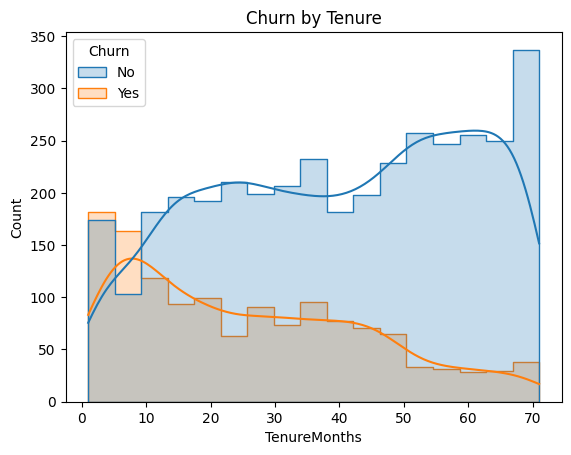

In [5]:
sns.histplot(data=df, x='TenureMonths', hue='Churn', kde=True, element='step')
plt.title('Churn by Tenure')
plt.show()

## Monthly charges vs churn

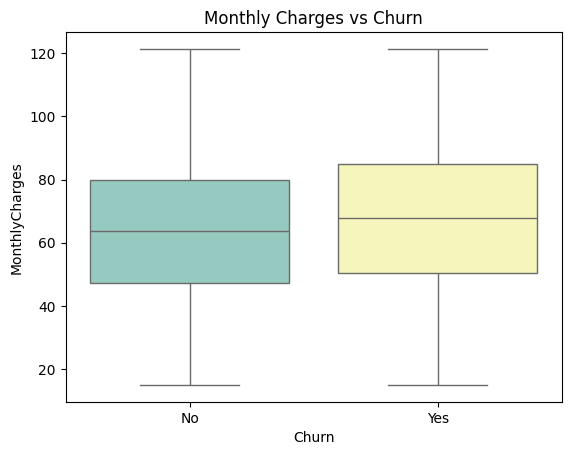

In [6]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set3', legend=False)
plt.title('Monthly Charges vs Churn')
plt.show()

## Churn by contract type

In [7]:
contract_churn = df.groupby('ContractType')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
contract_churn

ContractType
Month-to-Month    41.464299
One Year          13.511259
Two Year           4.222649
Name: Churn, dtype: float64

## Customer segmentation

In [8]:
df_seg, segment_summary = eda.customer_segmentation(df)
segment_summary

,Spend_Segment,Tenure_Segment,ChurnRate
0,High Spend,Established,41.379310
1,High Spend,Loyal,18.702290
2,High Spend,New,64.864865
3,Low Spend,Established,26.301370
4,Low Spend,Loyal,7.619048
5,Low Spend,New,58.139535
6,Medium Spend,Established,27.046866
7,Medium Spend,Loyal,10.926573
8,Medium Spend,New,52.091255


## Key EDA findings

In [9]:
answers = eda.answer_eda_questions(df)
for k, v in answers.items():
    print(v)

Correlation between tenure and churn: -0.292 (negative means longer tenure reduces churn)
Correlation between monthly charges and churn: 0.075
Highest churn contract type: Month-to-Month (41.5%)
Correlation between support calls and churn: 0.047
Highest churn payment method: Electronic Check (33.9%)
Highest churn age group: 18-30 (27.9%)
